# WRI Aqueduct riverine flood risk — quickstart

This notebook fetches **WRI Aqueduct Global Flood Analyzer (2015)** riverine flood-risk data through the `aqueduct` backend and maps it. The data is public (`files.wri.org`, CC-BY-4.0, no credentials): the expected exposure of GDP, population, and urban area to river flooding, aggregated by admin unit.

`download()` returns a pyramids `FeatureCollection` (a `geopandas.GeoDataFrame` subclass), so we can inspect it as a table and plot it directly.

## Setup

Import the facade. Downloads are cached under `out/`.

In [1]:
from earthlens.core import EarthLens

DATA = "out"

2026-08-09 21:46:11 | INFO | pyramids.base.config | Logging is configured.


## Download: population exposed to river flooding

Country-level **population affected**, under the 2030 SSP2 + RCP8.5 projection, for the 100-year flood. The first run downloads the ~7 MB country shapefile from WRI and caches it.

In [2]:
fc = EarthLens(
    "aqueduct",
    admin_level="country",
    metric="population_affected",
    year=2030,
    scenario="ssp2-rcp8p5",
    return_period=100,
    path=DATA,
    cache_dir=DATA,
).download()

print(type(fc).__name__, len(fc), "countries")
fc.columns.tolist()

2026-08-09 21:46:12.090 | INFO     | earthlens.aqueduct.backend:_cached_zip:317 - Aqueduct: downloading aqueduct_global_flood_risk_data_by_country_20150304.zip for admin level 'country'


2026-08-09 21:46:13.671 | INFO     | earthlens.aqueduct.backend:download:350 - Aqueduct country/population_affected/2030/ssp2-rcp8p5: 253 unit(s).


2026-08-09 21:46:13 | INFO | pyogrio._io | Created 253 records


2026-08-09 21:46:14.004 | INFO     | earthlens.aqueduct.backend:download:357 - Aqueduct: wrote 253 unit(s) to C:\python-environments\worktrees\earthlens\aqueduct-flood-risk\docs\examples\aqueduct\out\aqueduct_country_population_affected_2030_ssp2-rcp8p5.gpkg


FeatureCollection 253 countries


['unit_id', 'unit_name', 'rp_100', 'geometry']

The frame carries `unit_id`, `unit_name`, the `rp_100` exposure column, and the geometry. The ten countries with the most population exposed to a 100-year river flood:

In [3]:
top10 = (
    fc[["unit_name", "rp_100"]]
    .sort_values("rp_100", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10

,unit_name,rp_100
0,INDIA,194649632.0
1,CHINA,175204534.4
2,BANGLADESH,62675597.6
3,PAKISTAN,31048267.6
4,VIET NAM,29125134.8
5,EGYPT,20578658.3
6,INDONESIA,19225120.6
7,UNITED STATES,18592117.6
8,THAILAND,15979307.0
9,BRAZIL,15615181.0


## Map the exposure

A choropleth of population exposed to the 100-year river flood, by country.

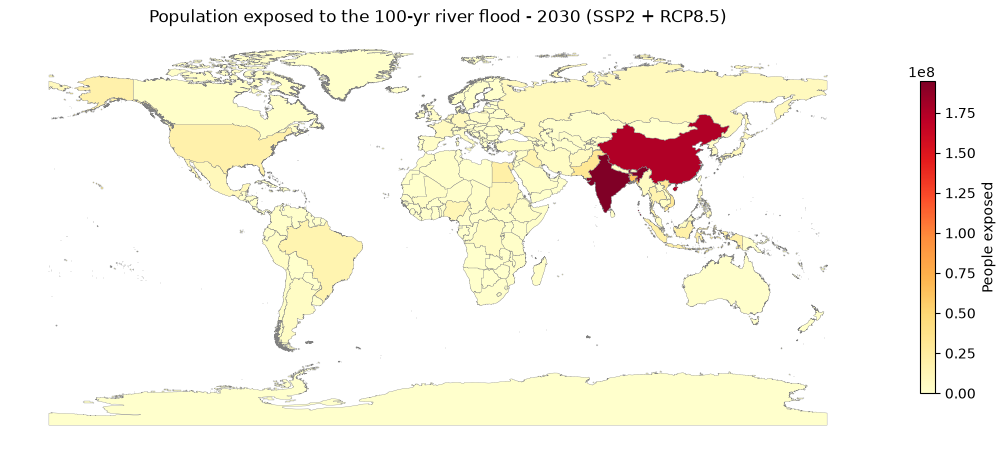

In [4]:
import matplotlib.pyplot as plt

ax = fc.plot(
    column="rp_100",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "People exposed", "shrink": 0.6},
    figsize=(11, 5.5),
    edgecolor="grey",
    linewidth=0.2,
    missing_kwds={"color": "#eeeeee"},
)
ax.set_title("Population exposed to the 100-yr river flood - 2030 (SSP2 + RCP8.5)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Top exposed countries

The same ten countries as a bar chart.

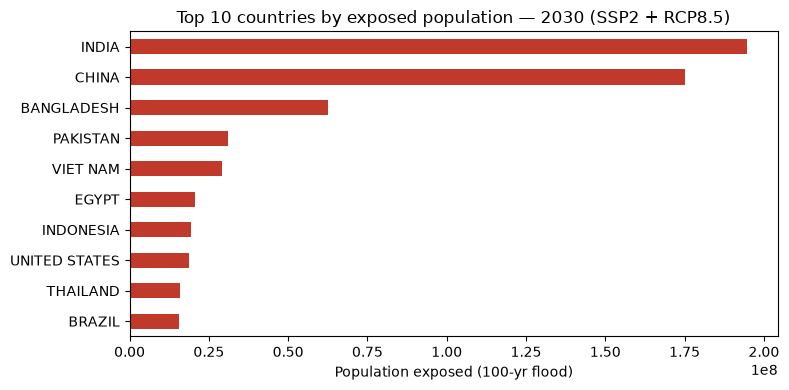

In [5]:
ax = top10.set_index("unit_name")["rp_100"].iloc[::-1].plot.barh(
    figsize=(8, 4), color="#c0392b"
)
ax.set_xlabel("Population exposed (100-yr flood)")
ax.set_ylabel("")
ax.set_title("Top 10 countries by exposed population — 2030 (SSP2 + RCP8.5)")
plt.tight_layout()
plt.show()

## Notes

- The values are **per-return-period exposure**, not a single expected-annual figure; pass a list to `return_period=` (or omit it for all nine magnitudes).
- `metric` can be `gdp_affected`, `population_affected`, or `urban_damage`; `admin_level` can be `country`, `state`, or `basin`.
- Coastal flooding and the 2050 / 2080 horizons are the paywalled 2020 product and are not available here.

Data: WRI Aqueduct Global Flood Analyzer 2015 (CC-BY-4.0). Attribution: *World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013*.